In [1]:
import pickle
import bw2io, bw2data
import bw2calc
import lca_algebraic as agb
import wurst as ws
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib import rcParams
plt.rcParams["font.family"] = "Times New Roman"

### what activities we wanna run the calculation? 

In [2]:
pkl_file = "filtered_agri_N201.pkl"
# Step 2: Load the file
with open(pkl_file, "rb") as f:
    agri = pickle.load(f)


In [3]:
bw2data.projects.set_current('iveo_v1')
bw2data.databases

Databases dictionary with 43 objects, including:
	SIB
	batteries
	batteries-NMC622-LTO
	batteries_LiS
	batteries_SIB
	battery_lithium-oxygen
	biosphere3
	ecoinvent 3.9.1
	ecoinvent_cutoff_3.9_remind_SSP1-PkBudg1150_2020
	ecoinvent_cutoff_3.9_remind_SSP1-PkBudg1150_2030
Use `list(this object)` to get the complete list.

In [4]:
eidb = 	bw2data.Database("ecoinvent 3.9.1")
print(len(eidb))

21238


In [10]:
# new method name:
[m for m in bw2data.methods if 'pGWP100 with fixed' in str(m) and 'prospective GWP100' in str(m)]

[('Climate Change prospective GWP100',
  'SSP119',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP119',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP119',
  '2050',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2050',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2050',
  'pGWP100 with fixed AGWPCO2')]

### let's compare GWP100 vs. pGWP100

In [21]:
gwp_fixedCO2_all = [
  ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2'),  
  ('Climate Change prospective GWP100',
  'SSP119',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP119',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP119',
  '2050',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP245',
  '2050',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2030',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2040',
  'pGWP100 with fixed AGWPCO2'),
 ('Climate Change prospective GWP100',
  'SSP585',
  '2050',
  'pGWP100 with fixed AGWPCO2')]

"""
[
     ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2'),
     ('IPCC 2021 - dpCFsSSP119_MY2030 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP245_MY2030 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP585_MY2030 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP119_MY2040 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP245_MY2040 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP585_MY2040 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP119_MY2050 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP245_MY2050 - year100', 'climate change', 'pGWP100'),
     ('IPCC 2021 - dpCFsSSP585_MY2050 - year100', 'climate change', 'pGWP100')
]
"""
len(gwp_fixedCO2_all)

10

In [12]:
def calculate_everything(activities, method_list):
    results = np.zeros((len(activities), len(method_list)))
    
    # Use only the .key from the first activity
    lca = bw2calc.LCA({activities[0][0]: 1}, method=method_list[0])  
    lca.lci()
    lca.decompose_technosphere()
    lca.lcia()

    #builds characterization_matrices in the same order as gwp_all, so later we can append col_names in final DF 
    characterization_matrices = []
    for method in method_list:
        lca.switch_method(method)
        characterization_matrices.append(lca.characterization_matrix.copy())
        
    for first, activity in enumerate(activities):
        activity_key = activity[0]  # Extract just the key
        activity_name = activity[1] 
        activity_rp = activity[2] 
        lca.redo_lci({activity_key: 1})
        
        for second, matrix in enumerate(characterization_matrices):
            results[first, second] = (matrix * lca.inventory).sum()
            
    return results


### filtering all act to be calculated from ecoinvent, takes long

In [13]:
activities = sorted([
    (e.key, e['name'], e['reference product'])
    for a in agri
    for e in eidb
    if e['name'] == a['name'] 
    and e['location'] == a['location'] 
    and e['reference product'] == a['reference product']
])


In [14]:
print(len(activities))
print(activities[36])

201
(('ecoinvent 3.9.1', '27772ec7fb0507af396d02619fabb574'), 'fattening of calves for beef production, feedlot', 'cattle for slaughtering, live weight')


### start calc with the selected pGWP100 method

In [22]:
from time import time
start = time()
lca_scores = calculate_everything(activities, gwp_fixedCO2_all)
elapsed = time() - start

In [23]:
print(f"calculate all filtered process N = {len(agri)},  in {elapsed:.2f} seconds, at {lca_scores.shape[0] * lca_scores.shape[1] / elapsed:.1f} calculations per second")


calculate all filtered process N = 201,  in 5.05 seconds, at 397.8 calculations per second


In [24]:
with open("calculated_GWP100_vs_pGWP100_N201_agri_fixedCO2.pkl", "wb") as f:
    pickle.dump(lca_scores, f)

In [ ]:
#with open("calculated_GWP100_vs_pGWP100_N201_agri_fixedCO2.pkl", "rb") as f:
#    lca_scores = pickle.load(f)

In [25]:
df = pd.DataFrame(lca_scores, columns=gwp_fixedCO2_all)

df['name'] = [act[1] for act in activities]
df['reference product'] = [act[2] for act in activities]
df['activity key'] = [act[0] for act in activities]
df = df[[ 'name', 'reference product', 'activity key' ] + list(df.columns[:-3])]
df

,name,reference product,activity key,"(IPCC 2021, climate change, GWP 100a, incl. H and bio CO2)","(Climate Change prospective GWP100, SSP119, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP119, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP119, 2050, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2050, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2050, pGWP100 with fixed AGWPCO2)"
0,"sheep production, for meat","sheep for slaughtering, live weight","(ecoinvent 3.9.1, 007e6b3a65b4c76d50ee97e28e38...",4.981426,4.571632,4.745854,4.799297,4.357298,4.416002,4.402627,4.093649,3.861186,3.834920
1,intensive beef cattle production on pasture,"cattle for slaughtering, live weight","(ecoinvent 3.9.1, 00dbb25d67f7aa1c39b4033b80e0...",18.557733,17.143174,17.679483,17.836573,16.410655,16.511818,16.381029,15.515580,14.619945,14.406930
2,intensive beef cattle production on pasture,"weaned heifers, live weight","(ecoinvent 3.9.1, 023e6028b4678d7c617385a4696c...",15.029473,13.883854,14.318199,14.445422,13.290605,13.372534,13.266611,12.565705,11.840350,11.667835
3,"pea seed production, organic, for sowing","pea seed, organic, for sowing","(ecoinvent 3.9.1, 02eaf3b9902c51b09fb4264f1557...",-0.719369,-0.967078,-0.961920,-0.978341,-0.936644,-0.868467,-0.810769,-0.917894,-0.815280,-0.707230
4,nutrient supply from NPK (26-15-15) fertiliser,"inorganic nitrogen fertiliser, as N","(ecoinvent 3.9.1, 055532213ec16a8039040f61becc...",9.168543,9.537250,9.422280,9.407595,9.363260,8.915968,8.505163,9.213176,8.541016,7.883342
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,"fava bean seed production, for sowing","fava bean seed, for sowing","(ecoinvent 3.9.1, f5fa91b7523f1b58d71801842fa0...",0.550995,0.611205,0.606703,0.609641,0.596892,0.566021,0.538182,0.585486,0.536972,0.489334
197,"operation, dried roughage store, non ventilated","operation, dried roughage store, non ventilated","(ecoinvent 3.9.1, fab72229ea8cb205676567685913...",0.013858,0.015311,0.015300,0.015414,0.014891,0.014218,0.013590,0.014526,0.013330,0.012233
198,"linseed seed production, at farm","linseed seed, at farm","(ecoinvent 3.9.1, fb5fc7ed373e16fef137f9bb92de...",-1.726566,-2.137513,-2.119918,-2.143704,-2.079925,-1.942439,-1.824279,-2.042433,-1.838168,-1.624911
199,olive production,olive,"(ecoinvent 3.9.1, fbc36664f672cf718c7425f58976...",-0.088549,-0.152111,-0.149335,-0.152808,-0.147427,-0.131429,-0.118639,-0.146039,-0.125327,-0.101088


### analysis & plot 

In [26]:

def create_correlation_matrix(scores_array, method_names):
    num_methods = scores_array.shape[1]
    correlations = np.eye(num_methods)  # Start with identity matrix (diagonal = 1)

    for row in range(num_methods):
        for col in range(row + 1, num_methods):  # Only upper triangle
            dataset_1 = scores_array[:, row]
            dataset_2 = scores_array[:, col]
            mask = (dataset_1 != 0) & (dataset_2 != 0)  # Exclude zero scores
            tau, _ = stats.kendalltau(dataset_1[mask], dataset_2[mask])
            corr = 0 if np.isnan(tau) else tau
            correlations[row, col] = correlations[col, row] = corr  # Symmetric

    return correlations, method_names


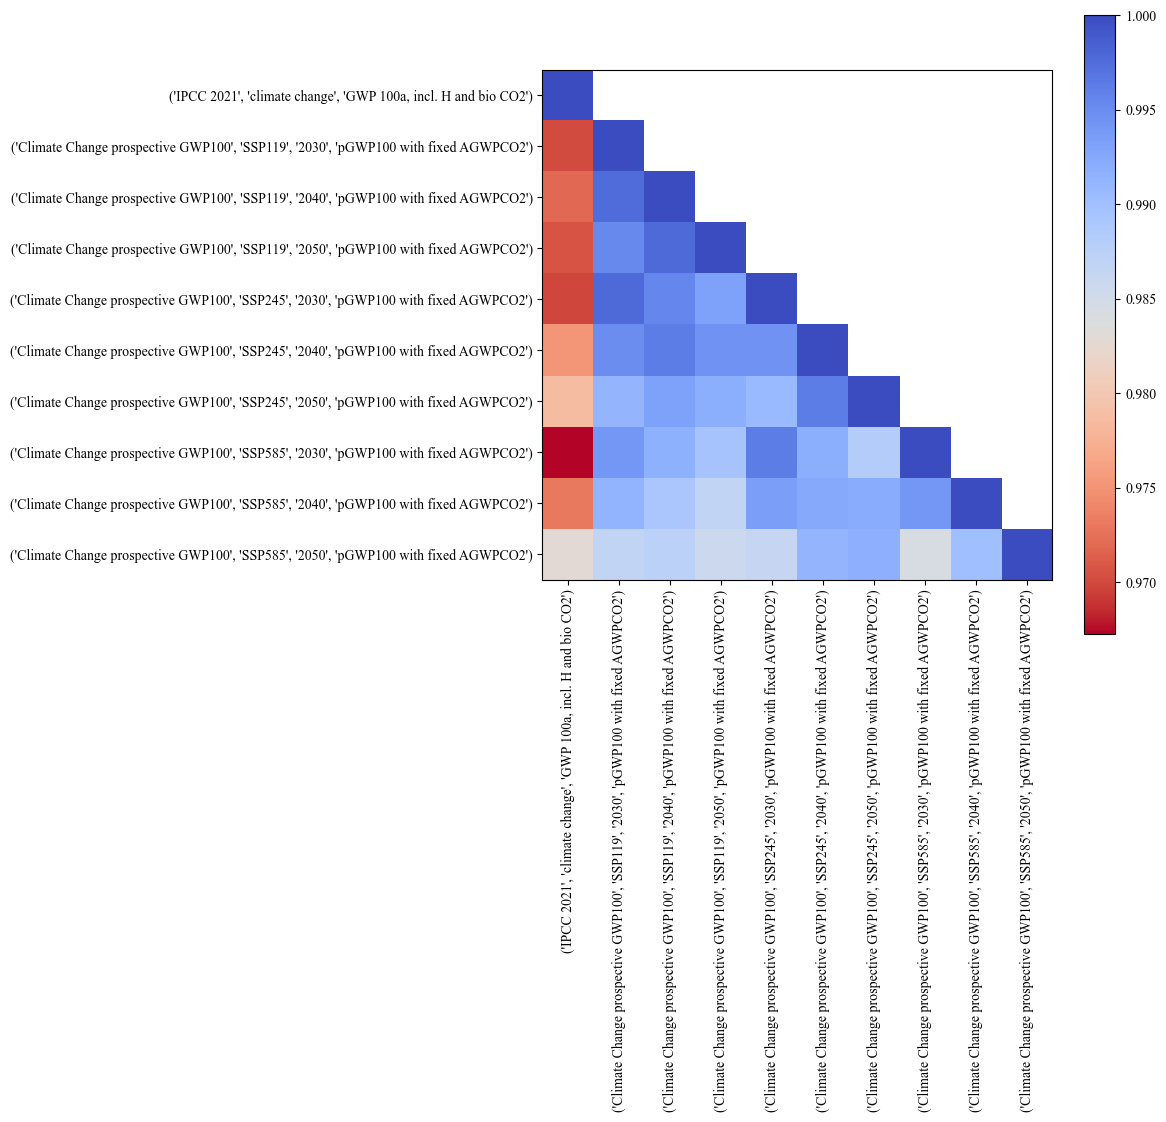

In [28]:
correlation_matrix, method_labels = create_correlation_matrix(lca_scores, gwp_fixedCO2_all)
# mask upper triangle only (keep diagonal = 1.0)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
masked_corr = np.ma.array(correlation_matrix, mask=mask)

fig, ax = plt.subplots(figsize=(12, 12))
cmap = plt.cm.coolwarm_r  # Reversed so RED = LOW, BLUE = HIGH

c = ax.imshow(masked_corr, cmap=cmap, vmin=masked_corr.min(), vmax=1.0)  #vmin dynamically change 

# labels
tick_labels = [str(m) for m in method_labels]
ax.set_xticks(np.arange(len(tick_labels)))
ax.set_yticks(np.arange(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=90, fontsize=10)
ax.set_yticklabels(tick_labels, fontsize=10)

cb = fig.colorbar(c, ax=ax, shrink=0.85)
cb.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig("correlation_matrix_pGWP_whfixedCO2_vsGWP_onN201_eidb-agri.png", dpi=300, bbox_inches='tight')

plt.show()


### top impacted activities 

In [29]:
def rank_activity_gwp_variation(df, top_n=10, method='perc'):
    """
    Get variation across GWP methods for each activity and return:
    1. DataFrame with added variation column
    2. Top N activities with highest variation
    Parameters:
    - df: DataFrame with metadata + GWP method columns
    - top_n: number of top varying activities to return
    - method: 'range', 'std', or 'perc'
    Returns:
    - df_with_variation: full DataFrame with new variation column
    - df_top_variation: top N activities sorted by variation
    """
    gwp_columns = df.columns[3:]  # assuming first 3 columns are metadata
    variation_col = f"variation_{method}"  # dynamically name the column


    if method == 'range':
        df[variation_col] = df[gwp_columns].max(axis=1) - df[gwp_columns].min(axis=1)
    elif method == 'std':
        df[variation_col] = df[gwp_columns].std(axis=1)
    elif method == 'perc': 
        #df['variation'] = (df[gwp_columns].max(axis=1) - df[gwp_columns].min(axis=1)) / df[gwp_columns].max(axis=1)
        max_val = df[gwp_columns].max(axis=1)
        min_val = df[gwp_columns].min(axis=1)
        raw_perc = (max_val - min_val) / max_val * 100
        df[variation_col] = raw_perc.round().astype('Int64')  # preserves NaN + int formatting 
        
    else:
        raise ValueError("method must be 'range' or 'std' or 'perc' ")

    df_top = df.sort_values(by=variation_col, ascending=False).head(top_n)
    
    return df, df_top


In [30]:
df = pd.DataFrame(lca_scores, columns=gwp_fixedCO2_all)
df['name'] = [act[1] for act in activities]
df['reference product'] = [act[2] for act in activities]
df['activity key'] = [act[0] for act in activities]
df = df[[ 'name', 'reference product', 'activity key' ] + list(df.columns[:-3])]

df2, df_top = rank_activity_gwp_variation (df, top_n=20, method = 'perc')

In [31]:
df_top

,name,reference product,activity key,"(IPCC 2021, climate change, GWP 100a, incl. H and bio CO2)","(Climate Change prospective GWP100, SSP119, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP119, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP119, 2050, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP245, 2050, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2030, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2040, pGWP100 with fixed AGWPCO2)","(Climate Change prospective GWP100, SSP585, 2050, pGWP100 with fixed AGWPCO2)",variation_perc
48,"maize seed production, organic, for sowing","maize seed, organic, for sowing","(ecoinvent 3.9.1, 35a4bc24ee7d1d5b1c5f368e13d7...",0.026763,-0.187107,-0.190293,-0.207185,-0.171650,-0.139512,-0.115014,-0.165887,-0.118581,-0.064144,874
164,"rice seed production, for sowing","rice seed, for sowing","(ecoinvent 3.9.1, c0e4d9479e0e88ac442c1db54720...",0.075815,-0.127394,-0.072127,-0.062105,-0.153291,-0.075105,-0.020889,-0.196691,-0.156712,-0.066885,359
117,"aubergine production, open field",aubergine,"(ecoinvent 3.9.1, 8adaa0ef50d1d821ccfacbb2ceae...",0.024973,-0.011239,-0.012989,-0.016364,-0.008373,-0.004674,-0.001951,-0.007001,-0.000430,0.006750,166
40,"grass seed production, organic, for sowing","grass seed, organic, for sowing","(ecoinvent 3.9.1, 2da12f3e810e0e181b78ac17396a...",0.261702,0.054840,0.047665,0.029754,0.066741,0.086992,0.100742,0.069593,0.100367,0.137967,89
127,"rice production, non-basmati","rice, non-basmati","(ecoinvent 3.9.1, 92386c6d580849768ba0ae1df128...",0.412956,0.176686,0.252268,0.269328,0.130834,0.221022,0.279713,0.062684,0.087779,0.183131,85
6,"rice production, non-basmati",straw,"(ecoinvent 3.9.1, 059f36dd739f9cec0d710c2fcdb7...",0.013393,0.005730,0.008182,0.008735,0.004243,0.007168,0.009072,0.002033,0.002847,0.005939,85
129,"milk production, from cow","cattle for slaughtering, live weight","(ecoinvent 3.9.1, 936da08864a9a3db33f7a6c8b16e...",1.618518,0.703729,0.892706,0.912435,0.596759,0.859211,1.029329,0.418105,0.519947,0.818060,74
95,"milk production, from cow",cow milk,"(ecoinvent 3.9.1, 65e92c1f24b04bb24bbb720b3b85...",0.278945,0.121285,0.153854,0.157254,0.102849,0.148081,0.177400,0.072059,0.089611,0.140989,74
69,"potato seed production, organic, for setting","potato seed, organic, for setting","(ecoinvent 3.9.1, 49f9d038ba35053208a503d7e5c2...",0.053529,0.027982,0.027827,0.025959,0.028520,0.031083,0.032612,0.027818,0.030458,0.034693,52
115,peach production,peach,"(ecoinvent 3.9.1, 872fe5c22a503f242edf79002621...",0.046656,0.024799,0.024979,0.023504,0.025070,0.027575,0.029097,0.024225,0.026546,0.030467,50


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_top_variation_profiles(df_top, gwp_columns, title, filename, font_family="Times New Roman"):
    """
    Plot top activities with highest GWP method variation in subplots.

    Parameters:
    - df_top: DataFrame with top N activities (e.g., from rank_activity_gwp_variation)
    - gwp_columns: List of GWP method columns (as-is, even if they're tuples)
    - title: Suptitle for the entire figure
    - filename: Path to save the figure (e.g., 'plot.png')
    - font_family: Optional global font (default: Times New Roman)
    """
    #  global font
    plt.rcParams["font.family"] = font_family
    # layout setup
    top_n = df_top.shape[0]
    ncols = 4
    nrows = int(np.ceil(top_n / ncols))
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axs = axs.flatten()

    # GWP method names to string for plotting
    x_labels = [str(col) for col in gwp_columns]

    for i, (idx, row) in enumerate(df_top.iterrows()):
        ax = axs[i]
        y = row[gwp_columns].astype(float)  # ensure numeric

        # Plot line
        ax.plot(x_labels, y, marker='o', linestyle='-', color='orange')

        # Highlight min and max
        min_idx = y.idxmin()
        max_idx = y.idxmax()
        ax.plot(str(min_idx), y[min_idx], marker='v', color='blue', markersize=10)
        ax.plot(str(max_idx), y[max_idx], marker='^', color='red', markersize=10)

        # Annotate largest % change from first point
        percent_changes = ((y - y.iloc[0]) / abs(y.iloc[0])) * 100
        largest_change_idx = percent_changes.abs().idxmax()
        percent_value = percent_changes[largest_change_idx]

        ax.annotate(f"{percent_value:.1f}%", 
                    xy=(str(largest_change_idx), y[largest_change_idx]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='black', fontweight='bold')

        #  title per panel
        name = row['name']
        ref_prod = row['reference product']
        label = f"{name}\n{ref_prod}"
        ax.set_title(label, fontsize=11)
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=90, fontsize=10)

        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.set_ylabel(r"(p)GWP100 [kg CO$_2$-eq]")

    # hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to accommodate title
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


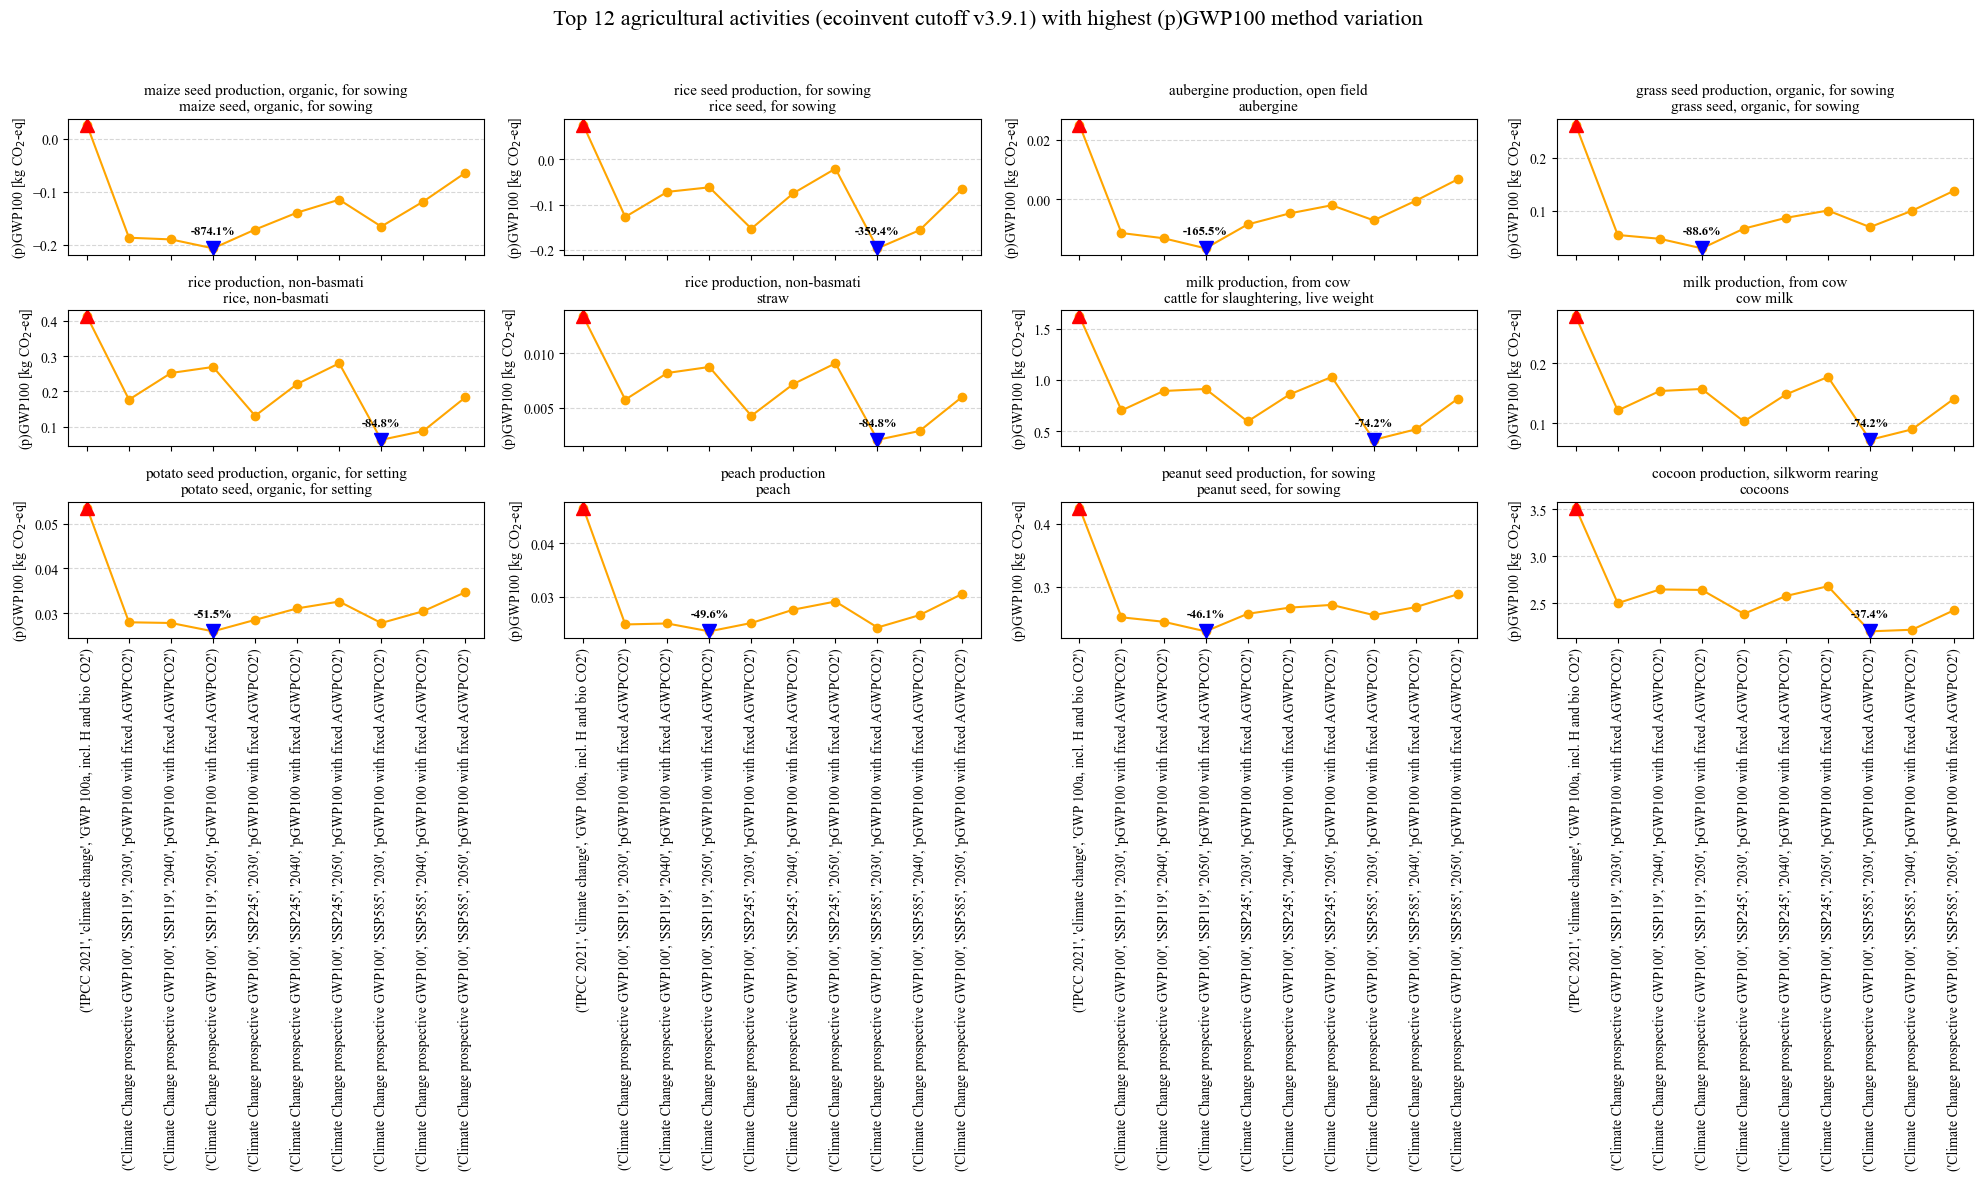

In [33]:
df = pd.DataFrame(lca_scores, columns=gwp_fixedCO2_all)
df['name'] = [act[1] for act in activities]
df['reference product'] = [act[2] for act in activities]
df['activity key'] = [act[0] for act in activities]
df = df[[ 'name', 'reference product', 'activity key' ] + list(df.columns[:-3])]

df2, df_top = rank_activity_gwp_variation (df, top_n=12, method = 'perc')

plot_top_variation_profiles(
    df_top=df_top, 
    gwp_columns=df.columns[3:-1],  # exclude metadata and new col 'variation'
    title="Top 12 agricultural activities (ecoinvent cutoff v3.9.1) with highest (p)GWP100 method variation",
    filename="top12_gwp_whfixedCO2_variation_lineplot_fromN201_eidb-agri.png"
)
